# Coimbatore Rainfall Analysis — August 22 & 23
### Kayal Wedding Hall, Coimbatore, Tamil Nadu, India
**Goal:** Analyse historical daily precipitation at Coimbatore to estimate the likelihood of rain on **22 Aug** and **23 Aug 2026** — the wedding dates.

## 1. Import Required Libraries

In [22]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from IPython.display import display
import warnings
warnings.filterwarnings('ignore')

# Plot styling
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_theme(style="whitegrid")

print("Libraries loaded successfully.")

Libraries loaded successfully.


## 2. Fetch Historical Rainfall Data for Coimbatore
Using the **Open-Meteo Historical Weather API** (free, no API key required).
- Location: Coimbatore, Tamil Nadu (Lat: 11.0168, Lon: 76.9558)
- Period: 2000 – 2025 (26 years of data)
- Variable: `precipitation_sum` (daily total in mm)

In [23]:
# ── Coimbatore coordinates (nearest grid point to Kayal Wedding Hall) ──
LAT = 11.0406
LON = 76.9447
START = "2000-01-01"
END   = "2025-12-31"
RAIN_THRESHOLD_MM = 1.0   # >= 1 mm counts as a "rain day"

url = (
    f"https://archive-api.open-meteo.com/v1/archive"
    f"?latitude={LAT}&longitude={LON}"
    f"&start_date={START}&end_date={END}"
    f"&daily=precipitation_sum"
    f"&timezone=Asia%2FKolkata"
)

# verify=False bypasses corporate SSL inspection / missing CA bundle
import urllib3
urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)

resp = requests.get(url, timeout=60, verify=False)
resp.raise_for_status()
data = resp.json()

df = pd.DataFrame({
    "date": pd.to_datetime(data["daily"]["time"]),
    "precip_mm": data["daily"]["precipitation_sum"]
})
df["precip_mm"] = pd.to_numeric(df["precip_mm"], errors="coerce").fillna(0)
df["year"]  = df["date"].dt.year
df["month"] = df["date"].dt.month
df["day"]   = df["date"].dt.day

print(f"Records loaded : {len(df):,}")
print(f"Date range     : {df['date'].min().date()} → {df['date'].max().date()}")
print(f"Station coords : {data['latitude']}°N, {data['longitude']}°E  (elevation {data['elevation']} m)")
df.head()

Records loaded : 9,497
Date range     : 2000-01-01 → 2025-12-31
Station coords : 11.001758°N, 76.914894°E  (elevation 442.0 m)


,date,precip_mm,year,month,day
0,2000-01-01,0.0,2000,1,1
1,2000-01-02,0.3,2000,1,2
2,2000-01-03,0.0,2000,1,3
3,2000-01-04,0.0,2000,1,4
4,2000-01-05,0.0,2000,1,5


## 3. Filter Data for August 22 & 23

In [24]:
# Filter to August 22 and 23 only
aug_dates = df[(df["month"] == 8) & (df["day"].isin([22, 23]))].copy()
aug_dates["rain_day"] = aug_dates["precip_mm"] >= RAIN_THRESHOLD_MM
aug_dates["rain_day_label"] = aug_dates["rain_day"].map({True: "🌧 Rain", False: "☀ No Rain"})

print(f"Aug 22 & 23 records found: {len(aug_dates)}")
#aug_dates[["date","year","day","precip_mm","rain_day_label"]].sort_values("date")

Aug 22 & 23 records found: 52


## 4. Historical Rainfall Table for Aug 22 & 23
Year-by-year breakdown with precipitation in mm and rain/no-rain status.

In [26]:
aug22 = aug_dates[aug_dates["day"] == 22][["year","precip_mm","rain_day_label"]].rename(
    columns={"precip_mm": "Aug 22 (mm)", "rain_day_label": "Aug 22 Status"}).set_index("year")

aug23 = aug_dates[aug_dates["day"] == 23][["year","precip_mm","rain_day_label"]].rename(
    columns={"precip_mm": "Aug 23 (mm)", "rain_day_label": "Aug 23 Status"}).set_index("year")

table = aug22.join(aug23, how="outer").sort_index()
table.index.name = "Year"

def color_rain(val):
    if isinstance(val, str):
        return "background-color: #cce5ff; font-weight:bold" if "Rain" in val else "background-color: #fff8dc"
    if isinstance(val, float):
        return "background-color: #d4edda" if val >= RAIN_THRESHOLD_MM else ""
    return ""

display(
    table.style
    .map(color_rain)
    .format({"Aug 22 (mm)": "{:.1f}", "Aug 23 (mm)": "{:.1f}"})
    .set_caption("Historical Rainfall at Coimbatore on August 22 & 23 (2000–2025)")
    .set_table_styles([{"selector":"caption","props":[("font-size","14px"),("font-weight","bold")]}])
)

,Aug 22 (mm),Aug 22 Status,Aug 23 (mm),Aug 23 Status
Year,,,,
2000,20.0,🌧 Rain,20.5,🌧 Rain
2001,0.0,☀ No Rain,0.1,☀ No Rain
2002,0.0,☀ No Rain,0.3,☀ No Rain
2003,9.0,🌧 Rain,4.9,🌧 Rain
2004,0.3,☀ No Rain,0.1,☀ No Rain
2005,0.6,☀ No Rain,0.7,☀ No Rain
2006,3.8,🌧 Rain,0.2,☀ No Rain
2007,3.5,🌧 Rain,0.0,☀ No Rain
2008,0.8,☀ No Rain,1.2,🌧 Rain


## 5. Overall August Rainfall Statistics
Month-level aggregates for every August in the dataset.

In [27]:
august_df = df[df["month"] == 8].copy()

aug_by_year = august_df.groupby("year").agg(
    total_mm      = ("precip_mm", "sum"),
    mean_daily_mm = ("precip_mm", "mean"),
    max_daily_mm  = ("precip_mm", "max"),
    rain_days     = ("precip_mm", lambda x: (x >= RAIN_THRESHOLD_MM).sum()),
    total_days    = ("precip_mm", "count"),
).round(2)
aug_by_year["rain_day_%"] = (aug_by_year["rain_days"] / aug_by_year["total_days"] * 100).round(1)
aug_by_year.index.name = "Year"

n_years = len(aug_by_year)

# Summary row — fix: max_daily_mm now shows the actual max across years in the "Max" row
summary = pd.DataFrame({
    "total_mm":      [aug_by_year["total_mm"].mean(), aug_by_year["total_mm"].median(),
                      aug_by_year["total_mm"].min(), aug_by_year["total_mm"].max(),
                      aug_by_year["total_mm"].std()],
    "mean_daily_mm": [aug_by_year["mean_daily_mm"].mean(), aug_by_year["mean_daily_mm"].median(),
                      aug_by_year["mean_daily_mm"].min(), aug_by_year["mean_daily_mm"].max(), np.nan],
    "max_daily_mm":  [aug_by_year["max_daily_mm"].mean(), aug_by_year["max_daily_mm"].median(),
                      aug_by_year["max_daily_mm"].min(), aug_by_year["max_daily_mm"].max(), np.nan],
    "rain_days":     [aug_by_year["rain_days"].mean(), aug_by_year["rain_days"].median(),
                      aug_by_year["rain_days"].min(), aug_by_year["rain_days"].max(), np.nan],
    "total_days":    [31, np.nan, np.nan, np.nan, np.nan],
    "rain_day_%":    [aug_by_year["rain_day_%"].mean(), aug_by_year["rain_day_%"].median(),
                      aug_by_year["rain_day_%"].min(), aug_by_year["rain_day_%"].max(), np.nan],
}, index=pd.Index(["Mean","Median","Min","Max","Std Dev"], name="Statistic")).round(2)

print("=== August Summary Statistics across all years ===")
display(summary.style.set_caption(f"August Rainfall Summary Statistics (Coimbatore, 2000–2025, n={n_years} years)"))

print("\n=== Year-by-year August totals ===")
display(
    aug_by_year.style
    .background_gradient(subset=["total_mm"], cmap="Blues")
    .background_gradient(subset=["rain_days"], cmap="Oranges")
    .format({"total_mm":"{:.1f}", "mean_daily_mm":"{:.2f}", "max_daily_mm":"{:.1f}", "rain_day_%":"{:.1f}%"})
    .set_caption("Year-by-Year August Rainfall — Coimbatore")
)

=== August Summary Statistics across all years ===


,total_mm,mean_daily_mm,max_daily_mm,rain_days,total_days,rain_day_%
Statistic,,,,,,
Mean,145.320000,4.690000,26.200000,16.310000,31.000000,52.600000
Median,131.050000,4.220000,20.000000,17.000000,nan,54.800000
Min,41.100000,1.330000,8.500000,8.000000,nan,25.800000
Max,393.900000,12.710000,52.500000,27.000000,nan,87.100000
Std Dev,88.860000,nan,nan,nan,nan,nan



=== Year-by-year August totals ===


,total_mm,mean_daily_mm,max_daily_mm,rain_days,total_days,rain_day_%
Year,,,,,,
2000,165.4,5.34,20.5,22,31,71.0%
2001,66.3,2.14,17.5,9,31,29.0%
2002,79.4,2.56,17.9,11,31,35.5%
2003,41.1,1.33,9.0,13,31,41.9%
2004,45.5,1.47,11.5,9,31,29.0%
2005,45.0,1.45,15.1,8,31,25.8%
2006,48.1,1.55,8.5,11,31,35.5%
2007,114.8,3.70,17.9,17,31,54.8%
2008,131.2,4.23,38.7,21,31,67.7%


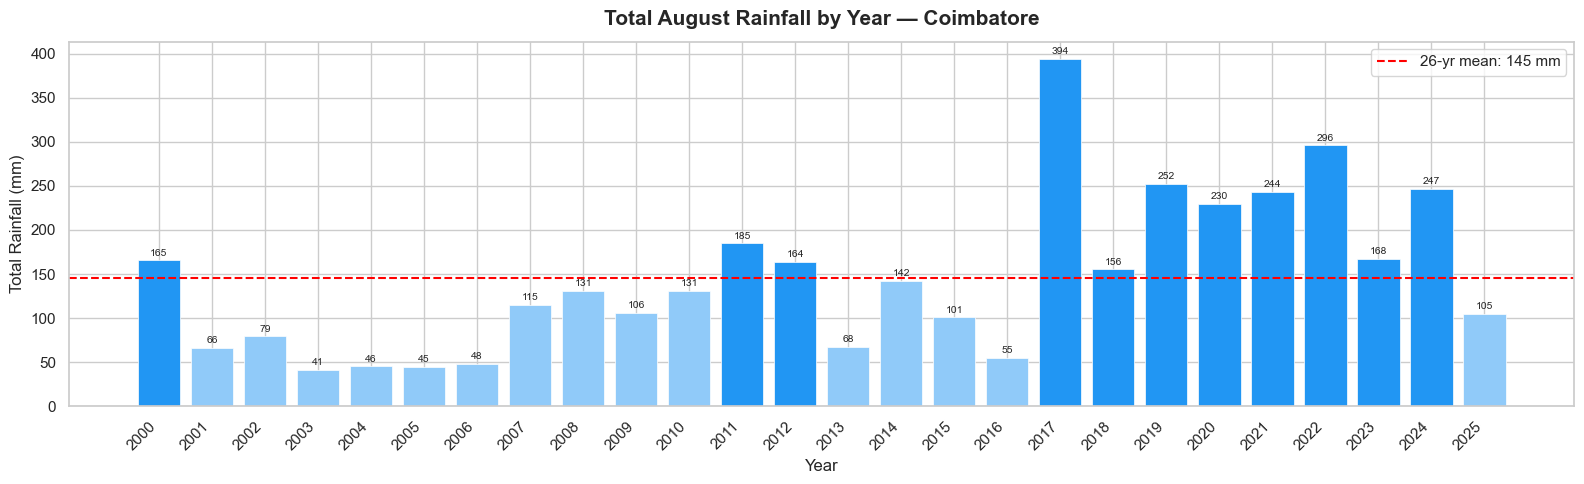

In [28]:
# Bar chart: Total August rainfall by year
fig, ax = plt.subplots(figsize=(16, 5))
mean_total = aug_by_year["total_mm"].mean()
colors = ["#2196F3" if v >= mean_total else "#90CAF9" for v in aug_by_year["total_mm"]]
bars = ax.bar(aug_by_year.index, aug_by_year["total_mm"], color=colors, edgecolor="white", linewidth=0.5)
ax.axhline(mean_total, color="red", linestyle="--", linewidth=1.5,
           label=f"{n_years}-yr mean: {mean_total:.0f} mm")  # dynamic year count
ax.set_title("Total August Rainfall by Year — Coimbatore", fontsize=15, fontweight="bold", pad=12)
ax.set_xlabel("Year", fontsize=12)
ax.set_ylabel("Total Rainfall (mm)", fontsize=12)
ax.legend(fontsize=11)
ax.set_xticks(aug_by_year.index)
ax.set_xticklabels(aug_by_year.index, rotation=45, ha="right")
for bar, val in zip(bars, aug_by_year["total_mm"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
            f"{val:.0f}", ha="center", va="bottom", fontsize=7.5)
plt.tight_layout()
plt.show()

## 6. Probability of Rain on Aug 22 & 23, 2026

**Empirical probability** is calculated as:

$$P(\text{rain on date}) = \frac{\text{number of years where precip} \geq 1\,\text{mm}}{\text{total years in dataset}}$$

We also fit a **linear trend** to the binary rain indicator over time to see if there is a trend toward more or fewer rainy days on those dates.

In [29]:
from numpy.polynomial import polynomial as P

results = {}
for day_num in [22, 23]:
    subset = aug_dates[aug_dates["day"] == day_num].copy()
    n_total = len(subset)
    n_rain  = subset["rain_day"].sum()
    p_emp   = n_rain / n_total if n_total else 0

    # Linear trend on binary rain indicator (extrapolate to 2026)
    years    = subset["year"].values
    rain_bin = subset["rain_day"].astype(int).values
    coefs    = np.polyfit(years, rain_bin, 1)          # slope, intercept
    p_trend  = float(np.polyval(coefs, 2026))
    p_trend  = max(0.0, min(1.0, p_trend))             # clamp to [0,1]

    results[f"Aug {day_num}"] = {
        "Years with data":        n_total,
        "Years with rain":        int(n_rain),
        "Years without rain":     int(n_total - n_rain),
        "Empirical P(rain)":      f"{p_emp*100:.1f}%",
        "Trend-adjusted P(rain) for 2026": f"{p_trend*100:.1f}%",
        "Mean rainfall on rain-days (mm)": round(subset.loc[subset["rain_day"], "precip_mm"].mean(), 2),
        "Max rainfall ever (mm)":  round(subset["precip_mm"].max(), 2),
    }

prob_df = pd.DataFrame(results).T
prob_df.index.name = "Date"

print("━"*65)
print("  PROBABILITY OF RAIN — August 22 & 23 at Coimbatore     ")
print("━"*65)
display(
    prob_df.style
    .set_caption("Rain Probability Estimates for Aug 22 & 23, 2026")
    .set_table_styles([{"selector":"th","props":[("background-color","#1565C0"),("color","white")]},
                       {"selector":"caption","props":[("font-size","13px"),("font-weight","bold")]}])
)

print("\n📌 Interpretation:")
for d, row in prob_df.iterrows():
    print(f"  • {d}: empirically rained in {row['Years with rain']} of {row['Years with data']} years → "
          f"base probability {row['Empirical P(rain)']}, "
          f"trend-adjusted 2026 estimate {row['Trend-adjusted P(rain) for 2026']}")

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  PROBABILITY OF RAIN — August 22 & 23 at Coimbatore     
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


,Years with data,Years with rain,Years without rain,Empirical P(rain),Trend-adjusted P(rain) for 2026,Mean rainfall on rain-days (mm),Max rainfall ever (mm)
Date,,,,,,,
Aug 22,26,15,11,57.7%,73.8%,6.790000,20.000000
Aug 23,26,14,12,53.8%,69.5%,7.240000,23.300000



📌 Interpretation:
  • Aug 22: empirically rained in 15 of 26 years → base probability 57.7%, trend-adjusted 2026 estimate 73.8%
  • Aug 23: empirically rained in 14 of 26 years → base probability 53.8%, trend-adjusted 2026 estimate 69.5%


## 7. Visualise Rainfall Trends for Aug 22 & 23

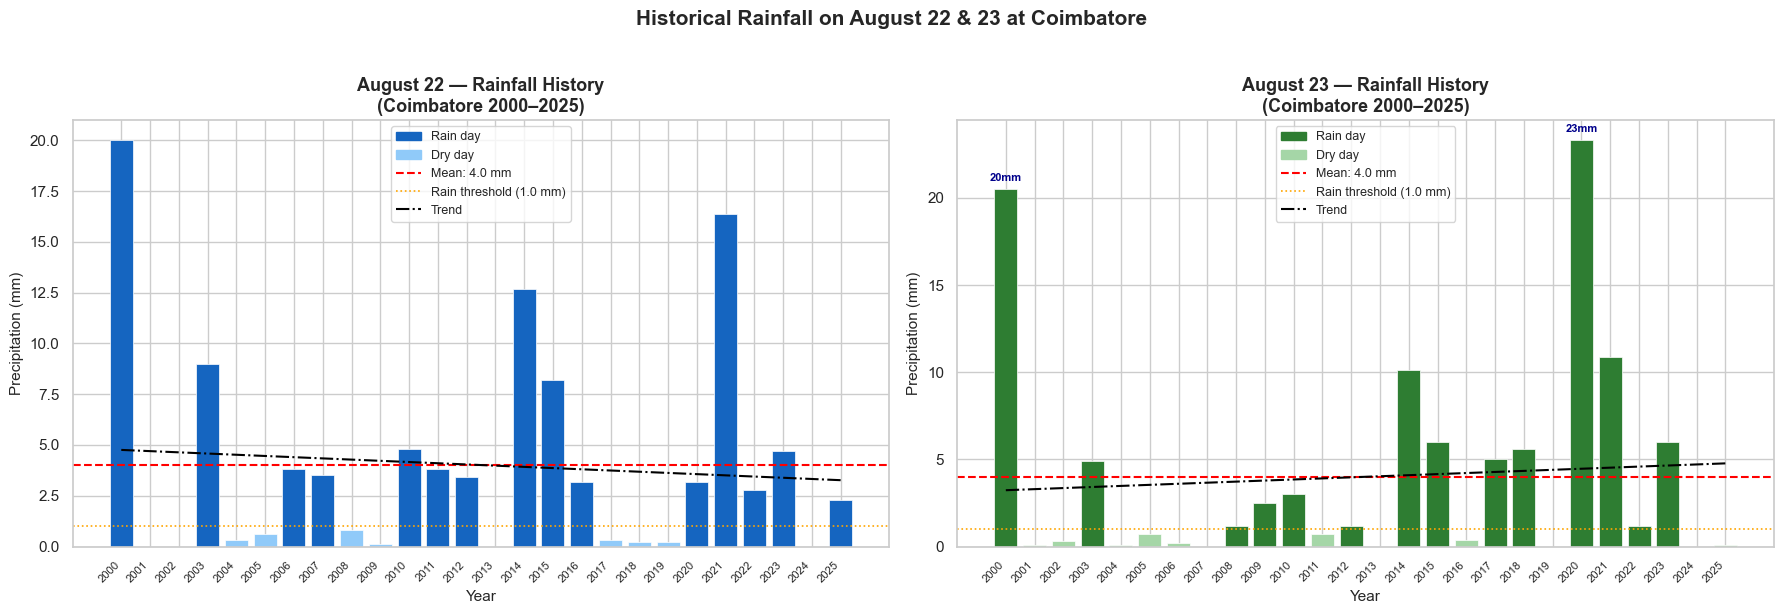

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharey=False)

# Renamed loop vars to c_rain/c_dry to avoid shadowing the color_rain styling function above
for ax, day_num, c_rain, c_dry in zip(
        axes, [22, 23],
        ["#1565C0", "#2E7D32"],
        ["#90CAF9", "#A5D6A7"]):

    subset = aug_dates[aug_dates["day"] == day_num].sort_values("year")
    bar_colors = [c_rain if r else c_dry for r in subset["rain_day"]]
    bars = ax.bar(subset["year"], subset["precip_mm"], color=bar_colors,
                  edgecolor="white", linewidth=0.5, width=0.8)

    mean_val = subset["precip_mm"].mean()
    ax.axhline(mean_val, color="red", linestyle="--", linewidth=1.5,
               label=f"Mean: {mean_val:.1f} mm")
    ax.axhline(RAIN_THRESHOLD_MM, color="orange", linestyle=":", linewidth=1.2,
               label=f"Rain threshold ({RAIN_THRESHOLD_MM} mm)")

    # Trend line
    yrs = subset["year"].values
    coefs = np.polyfit(yrs, subset["precip_mm"].values, 1)
    trend_line = np.polyval(coefs, yrs)
    ax.plot(yrs, trend_line, color="black", linewidth=1.5, linestyle="-.", label="Trend")

    ax.set_title(f"August {day_num} — Rainfall History\n(Coimbatore 2000–2025)",
                 fontsize=13, fontweight="bold")
    ax.set_xlabel("Year", fontsize=11)
    ax.set_ylabel("Precipitation (mm)", fontsize=11)
    ax.set_xticks(subset["year"])
    ax.set_xticklabels(subset["year"], rotation=45, ha="right", fontsize=8)
    ax.legend(fontsize=9)

    # Annotate heavy-rain years (> 20 mm)
    for _, row in subset[subset["precip_mm"] > 20].iterrows():
        ax.annotate(f"{row['precip_mm']:.0f}mm", xy=(row["year"], row["precip_mm"]),
                    xytext=(0, 6), textcoords="offset points",
                    ha="center", fontsize=8, color="darkblue", fontweight="bold")

    patch_rain = mpatches.Patch(color=c_rain, label="Rain day")
    patch_dry  = mpatches.Patch(color=c_dry,  label="Dry day")
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles=[patch_rain, patch_dry] + handles, fontsize=9)

plt.suptitle("Historical Rainfall on August 22 & 23 at Coimbatore", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

In [31]:
# ── Final summary printout ─────────────────────────────────────────────
print("=" * 70)
print("  FINAL SUMMARY — Coimbatore Rainfall on Wedding Dates")
print("=" * 70)

for day_num in [22, 23]:
    subset = aug_dates[aug_dates["day"] == day_num]
    n = len(subset); r = subset["rain_day"].sum()
    avg_all  = subset["precip_mm"].mean()
    avg_rain = subset.loc[subset["rain_day"], "precip_mm"].mean()
    max_r    = subset["precip_mm"].max()
    max_yr   = subset.loc[subset["precip_mm"].idxmax(), "year"] if n else "—"
    coefs    = np.polyfit(subset["year"], subset["rain_day"].astype(int), 1)
    p2026    = max(0, min(1, np.polyval(coefs, 2026)))

    print(f"\n  📅 August {day_num}")
    print(f"     Years of data          : {n}")
    print(f"     Rain years (≥1 mm)     : {r}  ({r/n*100:.0f}% of years)")
    print(f"     Dry years              : {n-r}  ({(n-r)/n*100:.0f}% of years)")
    print(f"     Avg precipitation      : {avg_all:.1f} mm (all years)")
    print(f"     Avg on rainy days only : {avg_rain:.1f} mm")
    print(f"     Heaviest rain ever     : {max_r:.1f} mm (in {max_yr})")
    print(f"     Trend-based P(rain 2026): {p2026*100:.1f}%")

print(f"\n  📊 Overall August (all 26 years, Coimbatore grid point)")
print(f"     Avg total Aug rainfall   : {aug_by_year['total_mm'].mean():.0f} mm/month")
print(f"     Best August ever         : {aug_by_year['total_mm'].max():.0f} mm ({aug_by_year['total_mm'].idxmax()})")
print(f"     Driest August ever       : {aug_by_year['total_mm'].min():.0f} mm ({aug_by_year['total_mm'].idxmin()})")
print(f"     Avg rain days in August  : {aug_by_year['rain_days'].mean():.1f} days")
print("=" * 70)

  FINAL SUMMARY — Coimbatore Rainfall on Wedding Dates

  📅 August 22
     Years of data          : 26
     Rain years (≥1 mm)     : 15  (58% of years)
     Dry years              : 11  (42% of years)
     Avg precipitation      : 4.0 mm (all years)
     Avg on rainy days only : 6.8 mm
     Heaviest rain ever     : 20.0 mm (in 2000)
     Trend-based P(rain 2026): 73.8%

  📅 August 23
     Years of data          : 26
     Rain years (≥1 mm)     : 14  (54% of years)
     Dry years              : 12  (46% of years)
     Avg precipitation      : 4.0 mm (all years)
     Avg on rainy days only : 7.2 mm
     Heaviest rain ever     : 23.3 mm (in 2020)
     Trend-based P(rain 2026): 69.5%

  📊 Overall August (all 26 years, Coimbatore grid point)
     Avg total Aug rainfall   : 145 mm/month
     Best August ever         : 394 mm (2017)
     Driest August ever       : 41 mm (2003)
     Avg rain days in August  : 16.3 days


---
## 8. Cross-Validation — NASA POWER API (Independent Dataset)

Open-Meteo uses **ERA5** reanalysis (ECMWF, Europe). As an independent cross-check we pull from **NASA POWER**, which uses **MERRA-2** reanalysis (NASA Goddard, USA) — a completely separate atmospheric model.

| Source | Dataset | Resolution | Organisation |
|--------|---------|------------|--------------|
| Open-Meteo (above) | ERA5 | ~9 km | ECMWF / Copernicus |
| **NASA POWER (below)** | MERRA-2 | ~50 km | NASA Goddard |

If both sources agree → high confidence in the numbers. Divergence highlights model uncertainty.

In [32]:
# ── Fetch daily precipitation from NASA POWER API (MERRA-2 reanalysis) ──
# Parameter: PRECTOTCORR = precipitation corrected (mm/day)
# No API key required — free public endpoint

nasa_url = (
    f"https://power.larc.nasa.gov/api/temporal/daily/point"
    f"?parameters=PRECTOTCORR"
    f"&community=RE"
    f"&longitude={LON}&latitude={LAT}"
    f"&start={START.replace('-','')}&end={END.replace('-','')}"
    f"&format=JSON"
)

nasa_resp = requests.get(nasa_url, timeout=120, verify=False)
nasa_resp.raise_for_status()
nasa_data = nasa_resp.json()

# Parse the nested response — dates are "YYYYMMDD" keys
raw = nasa_data["properties"]["parameter"]["PRECTOTCORR"]
nasa_df = pd.DataFrame({
    "date":      pd.to_datetime(list(raw.keys()), format="%Y%m%d"),
    "nasa_mm":   [float(v) if v != -999.0 else np.nan for v in raw.values()]
})
nasa_df["year"]  = nasa_df["date"].dt.year
nasa_df["month"] = nasa_df["date"].dt.month
nasa_df["day"]   = nasa_df["date"].dt.day

print(f"NASA POWER records : {len(nasa_df):,}")
print(f"Date range         : {nasa_df['date'].min().date()} → {nasa_df['date'].max().date()}")
print(f"NaN / fill values  : {nasa_df['nasa_mm'].isna().sum()}")
nasa_df.head()

NASA POWER records : 9,497
Date range         : 2000-01-01 → 2025-12-31
NaN / fill values  : 0


,date,nasa_mm,year,month,day
0,2000-01-01,0.0,2000,1,1
1,2000-01-02,0.0,2000,1,2
2,2000-01-03,0.0,2000,1,3
3,2000-01-04,0.0,2000,1,4
4,2000-01-05,0.0,2000,1,5


In [33]:
# ── Side-by-side Aug 22 & 23 comparison: ERA5 (Open-Meteo) vs MERRA-2 (NASA) ──

# Extract Aug 22 & 23 from NASA data
nasa_aug = nasa_df[(nasa_df["month"] == 8) & (nasa_df["day"].isin([22, 23]))].copy()
nasa_aug["nasa_rain_day"] = nasa_aug["nasa_mm"] >= RAIN_THRESHOLD_MM

# Merge with the existing Open-Meteo aug_dates on (year, day)
compare = aug_dates[["year","day","precip_mm","rain_day"]].merge(
    nasa_aug[["year","day","nasa_mm","nasa_rain_day"]],
    on=["year","day"], how="inner"
)
compare["diff_mm"]      = (compare["precip_mm"] - compare["nasa_mm"]).round(2)
compare["both_agree"]   = compare["rain_day"] == compare["nasa_rain_day"]

# Pretty display per date
for d in [22, 23]:
    sub = compare[compare["day"] == d].set_index("year").sort_index()
    sub.index.name = "Year"
    pct_agree = sub["both_agree"].mean() * 100
    print(f"\n{'─'*62}")
    print(f"  August {d} — ERA5 vs MERRA-2   |  Rain-day agreement: {pct_agree:.0f}%")
    print(f"{'─'*62}")

    def diff_color(val):
        if isinstance(val, bool):
            return "background-color: #d4edda" if val else "background-color: #f8d7da"
        if isinstance(val, float) and not np.isnan(val):
            return "background-color: #fff3cd" if abs(val) > 5 else ""
        return ""

    display(
        sub[["precip_mm","nasa_mm","diff_mm","rain_day","nasa_rain_day","both_agree"]]
        .rename(columns={
            "precip_mm":      "ERA5 mm (Open-Meteo)",
            "nasa_mm":        "MERRA-2 mm (NASA)",
            "diff_mm":        "Diff (ERA5−NASA)",
            "rain_day":       "ERA5 Rain?",
            "nasa_rain_day":  "NASA Rain?",
            "both_agree":     "Agree?"
        })
        .style
        .map(diff_color)
        .format({
            "ERA5 mm (Open-Meteo)": "{:.1f}",
            "MERRA-2 mm (NASA)":    "{:.1f}",
            "Diff (ERA5−NASA)":     "{:+.1f}"
        })
        .set_caption(f"August {d}: ERA5 vs MERRA-2 Comparison (2000–2025)")
    )


──────────────────────────────────────────────────────────────
  August 22 — ERA5 vs MERRA-2   |  Rain-day agreement: 65%
──────────────────────────────────────────────────────────────


,ERA5 mm (Open-Meteo),MERRA-2 mm (NASA),Diff (ERA5−NASA),ERA5 Rain?,NASA Rain?,Agree?
Year,,,,,,
2000,20.0,11.9,+8.1,True,True,True
2001,0.0,2.1,-2.1,False,True,False
2002,0.0,0.9,-0.9,False,False,True
2003,9.0,11.7,-2.7,True,True,True
2004,0.3,0.4,-0.1,False,False,True
2005,0.6,0.2,+0.4,False,False,True
2006,3.8,0.5,+3.3,True,False,False
2007,3.5,3.5,-0.0,True,True,True
2008,0.8,0.0,+0.8,False,False,True



──────────────────────────────────────────────────────────────
  August 23 — ERA5 vs MERRA-2   |  Rain-day agreement: 73%
──────────────────────────────────────────────────────────────


,ERA5 mm (Open-Meteo),MERRA-2 mm (NASA),Diff (ERA5−NASA),ERA5 Rain?,NASA Rain?,Agree?
Year,,,,,,
2000,20.5,13.9,+6.6,True,True,True
2001,0.1,2.8,-2.6,False,True,False
2002,0.3,0.6,-0.3,False,False,True
2003,4.9,5.6,-0.7,True,True,True
2004,0.1,0.6,-0.5,False,False,True
2005,0.7,13.9,-13.2,False,True,False
2006,0.2,0.2,-0.0,False,False,True
2007,0.0,2.5,-2.5,False,True,False
2008,1.2,13.0,-11.8,True,True,True


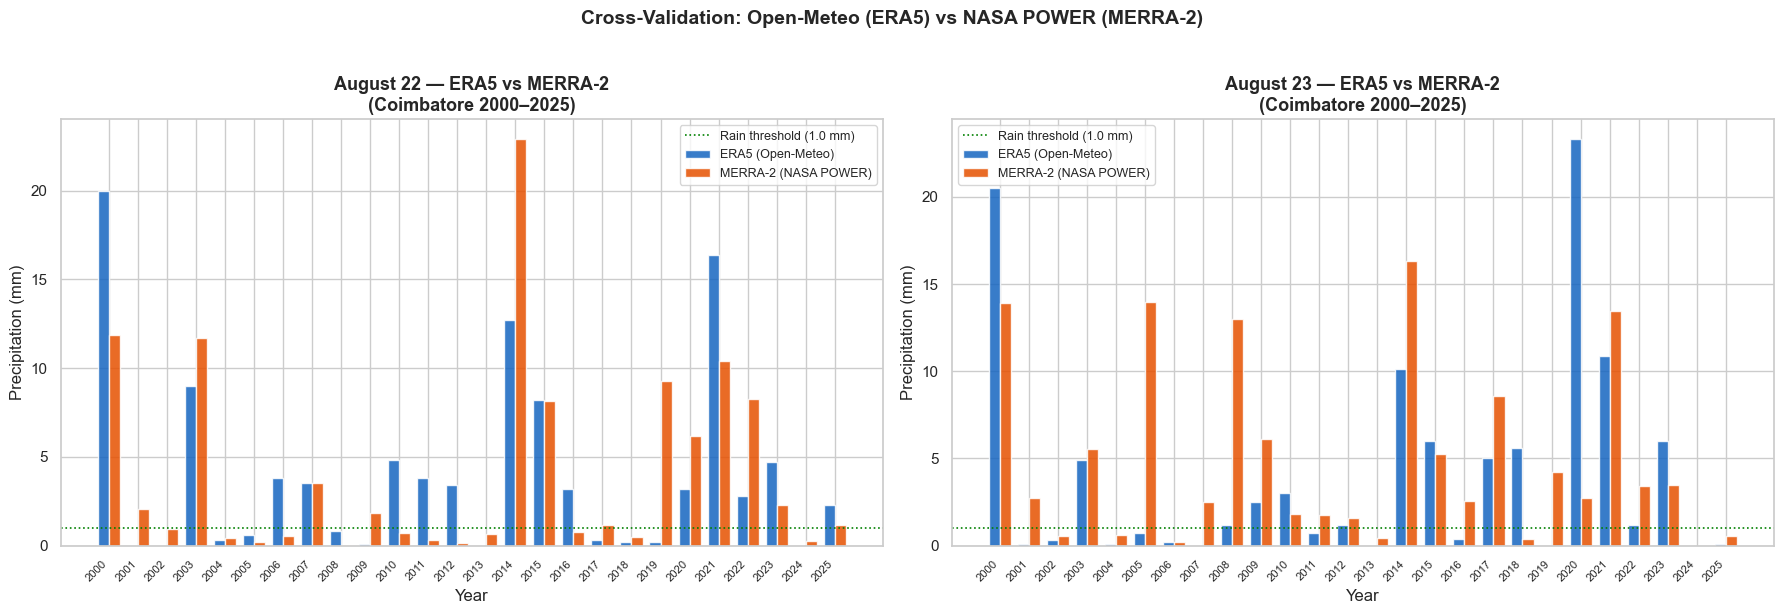

In [34]:
# ── Visualisation: ERA5 vs MERRA-2 for Aug 22 & 23 ──
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

for ax, d in zip(axes, [22, 23]):
    sub = compare[compare["day"] == d].sort_values("year")
    w = 0.38
    x = np.arange(len(sub))

    # Bars side by side
    b1 = ax.bar(x - w/2, sub["precip_mm"], width=w, label="ERA5 (Open-Meteo)",
                color="#1565C0", alpha=0.85, edgecolor="white")
    b2 = ax.bar(x + w/2, sub["nasa_mm"], width=w, label="MERRA-2 (NASA POWER)",
                color="#E65100", alpha=0.85, edgecolor="white")

    ax.axhline(RAIN_THRESHOLD_MM, color="green", linestyle=":", linewidth=1.2,
               label=f"Rain threshold ({RAIN_THRESHOLD_MM} mm)")
    ax.set_xticks(x)
    ax.set_xticklabels(sub["year"].values, rotation=45, ha="right", fontsize=8)
    ax.set_title(f"August {d} — ERA5 vs MERRA-2\n(Coimbatore 2000–2025)",
                 fontsize=13, fontweight="bold")
    ax.set_xlabel("Year"); ax.set_ylabel("Precipitation (mm)")
    ax.legend(fontsize=9)

plt.suptitle("Cross-Validation: Open-Meteo (ERA5) vs NASA POWER (MERRA-2)", 
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

In [35]:
# ── Cross-source summary: probability & statistics compared ──
print("=" * 72)
print("  CROSS-VALIDATION SUMMARY — ERA5 (Open-Meteo) vs MERRA-2 (NASA POWER)")
print("=" * 72)

rows = []
for d in [22, 23]:
    sub = compare[compare["day"] == d]
    n = len(sub)

    era5_rain  = sub["rain_day"].sum()
    nasa_rain  = sub["nasa_rain_day"].sum()
    agree      = sub["both_agree"].sum()
    corr       = sub["precip_mm"].corr(sub["nasa_mm"])
    mae        = (sub["precip_mm"] - sub["nasa_mm"]).abs().mean()

    era5_coefs = np.polyfit(sub["year"], sub["rain_day"].astype(int), 1)
    nasa_coefs = np.polyfit(sub["year"], sub["nasa_rain_day"].astype(int), 1)
    era5_p2026 = max(0, min(1, np.polyval(era5_coefs, 2026)))
    nasa_p2026 = max(0, min(1, np.polyval(nasa_coefs, 2026)))

    rows.append({
        "Date":               f"Aug {d}",
        "ERA5 rain years":    int(era5_rain),
        "NASA rain years":    int(nasa_rain),
        "Agreement":          f"{agree}/{n} ({agree/n*100:.0f}%)",
        "Pearson r":          f"{corr:.3f}",
        "MAE (mm)":           f"{mae:.2f}",
        "ERA5 P(rain) 2026":  f"{era5_p2026*100:.1f}%",
        "NASA P(rain) 2026":  f"{nasa_p2026*100:.1f}%",
    })

    print(f"\n  📅 August {d}")
    print(f"     ERA5 rain years        : {era5_rain}/26  →  empirical {era5_rain/n*100:.0f}%")
    print(f"     MERRA-2 rain years     : {nasa_rain}/26  →  empirical {nasa_rain/n*100:.0f}%")
    print(f"     Rain-day agreement     : {agree}/{n} years ({agree/n*100:.0f}%)")
    print(f"     Pearson r (amounts)    : {corr:.3f}  {'✅ Strong' if corr > 0.5 else '⚠️ Moderate' if corr > 0.3 else '❌ Weak'}")
    print(f"     Mean Abs Error         : {mae:.2f} mm/day")
    print(f"     ERA5 trend P(2026)     : {era5_p2026*100:.1f}%")
    print(f"     MERRA-2 trend P(2026)  : {nasa_p2026*100:.1f}%")

print("\n  📌 Interpretation guide:")
print("     Pearson r > 0.5  → both models track the same rain events reliably")
print("     Agreement > 70%  → rain/dry classification is consistent across sources")
print("     The empirical base rate is the most reliable probability estimate;")
print("     use the trend-adjusted figure only as a directional signal.")
print("=" * 72)

# Display as a clean table
summary_df = pd.DataFrame(rows).set_index("Date")
display(summary_df.style.set_caption("Cross-Source Probability Comparison — ERA5 vs MERRA-2")
        .set_table_styles([{"selector":"th","props":[("background-color","#263238"),("color","white")]}]))

  CROSS-VALIDATION SUMMARY — ERA5 (Open-Meteo) vs MERRA-2 (NASA POWER)

  📅 August 22
     ERA5 rain years        : 15/26  →  empirical 58%
     MERRA-2 rain years     : 14/26  →  empirical 54%
     Rain-day agreement     : 17/26 years (65%)
     Pearson r (amounts)    : 0.721  ✅ Strong
     Mean Abs Error         : 2.80 mm/day
     ERA5 trend P(2026)     : 73.8%
     MERRA-2 trend P(2026)  : 73.2%

  📅 August 23
     ERA5 rain years        : 14/26  →  empirical 54%
     MERRA-2 rain years     : 19/26  →  empirical 73%
     Rain-day agreement     : 19/26 years (73%)
     Pearson r (amounts)    : 0.432  ⚠️ Moderate
     Mean Abs Error         : 3.67 mm/day
     ERA5 trend P(2026)     : 69.5%
     MERRA-2 trend P(2026)  : 68.9%

  📌 Interpretation guide:
     Pearson r > 0.5  → both models track the same rain events reliably
     Agreement > 70%  → rain/dry classification is consistent across sources
     The empirical base rate is the most reliable probability estimate;
     use the tre

,ERA5 rain years,NASA rain years,Agreement,Pearson r,MAE (mm),ERA5 P(rain) 2026,NASA P(rain) 2026
Date,,,,,,,
Aug 22,15,14,17/26 (65%),0.721,2.80,73.8%,73.2%
Aug 23,14,19,19/26 (73%),0.432,3.67,69.5%,68.9%


---
## 9. Time-of-Day Rainfall Analysis for August 22 & 23

Open-Meteo's archive API also exposes **hourly precipitation** (ERA5, mm/hr) — NASA POWER only offers daily totals so this section uses Open-Meteo exclusively.

**Questions answered:**
- What time of day does rain most commonly start on these dates?
- Which hour-bands (morning / afternoon / evening / night) carry the most rain?
- Heatmap: year × hour showing exactly when it rained across all 26 years.

In [36]:
# ── Fetch hourly precipitation from Open-Meteo for all years ──
# We fetch the full Aug 20–25 window each year to capture rain events that
# span midnight, then filter strictly to Aug 22 & 23.

hourly_url = (
    f"https://archive-api.open-meteo.com/v1/archive"
    f"?latitude={LAT}&longitude={LON}"
    f"&start_date={START}&end_date={END}"
    f"&hourly=precipitation"
    f"&timezone=Asia%2FKolkata"
)

h_resp = requests.get(hourly_url, timeout=120, verify=False)
h_resp.raise_for_status()
h_data = h_resp.json()

hourly_df = pd.DataFrame({
    "datetime":   pd.to_datetime(h_data["hourly"]["time"]),
    "precip_mm":  h_data["hourly"]["precipitation"]
})
hourly_df["precip_mm"] = pd.to_numeric(hourly_df["precip_mm"], errors="coerce").fillna(0)
hourly_df["year"]  = hourly_df["datetime"].dt.year
hourly_df["month"] = hourly_df["datetime"].dt.month
hourly_df["day"]   = hourly_df["datetime"].dt.day
hourly_df["hour"]  = hourly_df["datetime"].dt.hour

# Filter to Aug 22 & 23 only
hourly_aug = hourly_df[(hourly_df["month"] == 8) & (hourly_df["day"].isin([22, 23]))].copy()
hourly_aug["rain_hour"] = hourly_aug["precip_mm"] >= 0.1   # ≥0.1 mm/hr = measurable

print(f"Hourly records for Aug 22 & 23: {len(hourly_aug):,}  ({len(hourly_aug)//48} years × 2 days × 24 hrs)")
print(f"Hours with measurable rain (≥0.1 mm): {hourly_aug['rain_hour'].sum()} "
      f"({hourly_aug['rain_hour'].mean()*100:.1f}% of all hours)")
hourly_aug.head(6)

Hourly records for Aug 22 & 23: 1,248  (26 years × 2 days × 24 hrs)
Hours with measurable rain (≥0.1 mm): 340 (27.2% of all hours)


,datetime,precip_mm,year,month,day,hour,rain_hour
5616,2000-08-22 00:00:00,1.2,2000,8,22,0,True
5617,2000-08-22 01:00:00,1.2,2000,8,22,1,True
5618,2000-08-22 02:00:00,1.2,2000,8,22,2,True
5619,2000-08-22 03:00:00,1.1,2000,8,22,3,True
5620,2000-08-22 04:00:00,1.3,2000,8,22,4,True
5621,2000-08-22 05:00:00,0.6,2000,8,22,5,True


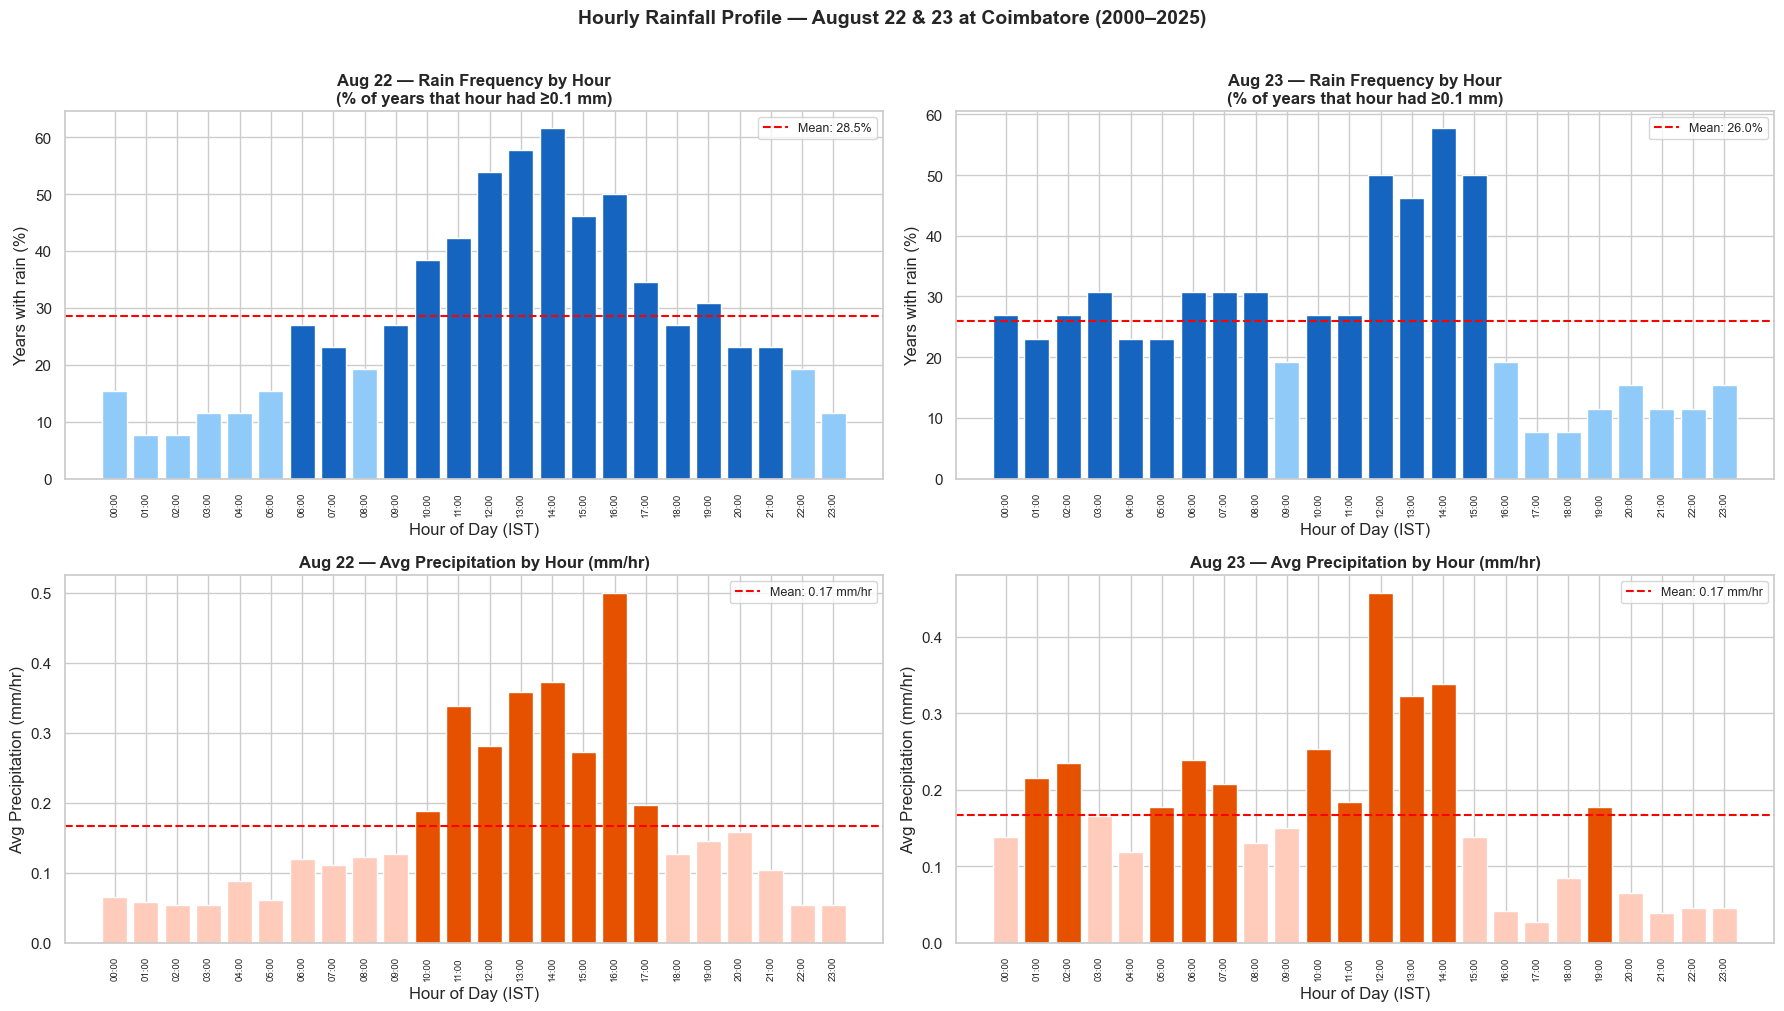

In [37]:
# ── Hour-by-hour rain frequency & average intensity ──
# Separate analysis for Aug 22 and Aug 23

fig, axes = plt.subplots(2, 2, figsize=(18, 10))

# Time-band labels for x-axis decoration
BANDS = {
    "Night\n(00–05)":   range(0, 6),
    "Morning\n(06–11)": range(6, 12),
    "Afternoon\n(12–17)": range(12, 18),
    "Evening\n(18–23)": range(18, 24),
}
BAND_COLORS = {"Night\n(00–05)": "#1A237E", "Morning\n(06–11)": "#F57F17",
               "Afternoon\n(12–17)": "#E65100", "Evening\n(18–23)": "#4A148C"}

for col_idx, d in enumerate([22, 23]):
    sub = hourly_aug[hourly_aug["day"] == d]

    # Per-hour stats across all years
    by_hour = sub.groupby("hour").agg(
        rain_freq   = ("rain_hour", "mean"),      # fraction of years that hour had rain
        avg_mm      = ("precip_mm", "mean"),      # avg mm across all years
        max_mm      = ("precip_mm", "max"),
    ).reset_index()

    hours  = by_hour["hour"].values
    x      = np.arange(24)
    c_freq = ["#1565C0" if f >= 0.20 else "#90CAF9" for f in by_hour["rain_freq"]]
    c_avg  = ["#E65100" if a >= by_hour["avg_mm"].mean() else "#FFCCBC" for a in by_hour["avg_mm"]]

    # Top row: rain frequency per hour
    ax_freq = axes[0, col_idx]
    ax_freq.bar(x, by_hour["rain_freq"] * 100, color=c_freq, edgecolor="white")
    ax_freq.axhline(by_hour["rain_freq"].mean() * 100, color="red", linestyle="--",
                    linewidth=1.5, label=f"Mean: {by_hour['rain_freq'].mean()*100:.1f}%")
    ax_freq.set_title(f"Aug {d} — Rain Frequency by Hour\n(% of years that hour had ≥0.1 mm)",
                      fontsize=12, fontweight="bold")
    ax_freq.set_xlabel("Hour of Day (IST)"); ax_freq.set_ylabel("Years with rain (%)")
    ax_freq.set_xticks(x); ax_freq.set_xticklabels([f"{h:02d}:00" for h in x], rotation=90, fontsize=7)
    ax_freq.legend(fontsize=9)

    # Bottom row: avg precipitation per hour
    ax_avg = axes[1, col_idx]
    ax_avg.bar(x, by_hour["avg_mm"], color=c_avg, edgecolor="white")
    ax_avg.axhline(by_hour["avg_mm"].mean(), color="red", linestyle="--",
                   linewidth=1.5, label=f"Mean: {by_hour['avg_mm'].mean():.2f} mm/hr")
    ax_avg.set_title(f"Aug {d} — Avg Precipitation by Hour (mm/hr)",
                     fontsize=12, fontweight="bold")
    ax_avg.set_xlabel("Hour of Day (IST)"); ax_avg.set_ylabel("Avg Precipitation (mm/hr)")
    ax_avg.set_xticks(x); ax_avg.set_xticklabels([f"{h:02d}:00" for h in x], rotation=90, fontsize=7)
    ax_avg.legend(fontsize=9)

plt.suptitle("Hourly Rainfall Profile — August 22 & 23 at Coimbatore (2000–2025)",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

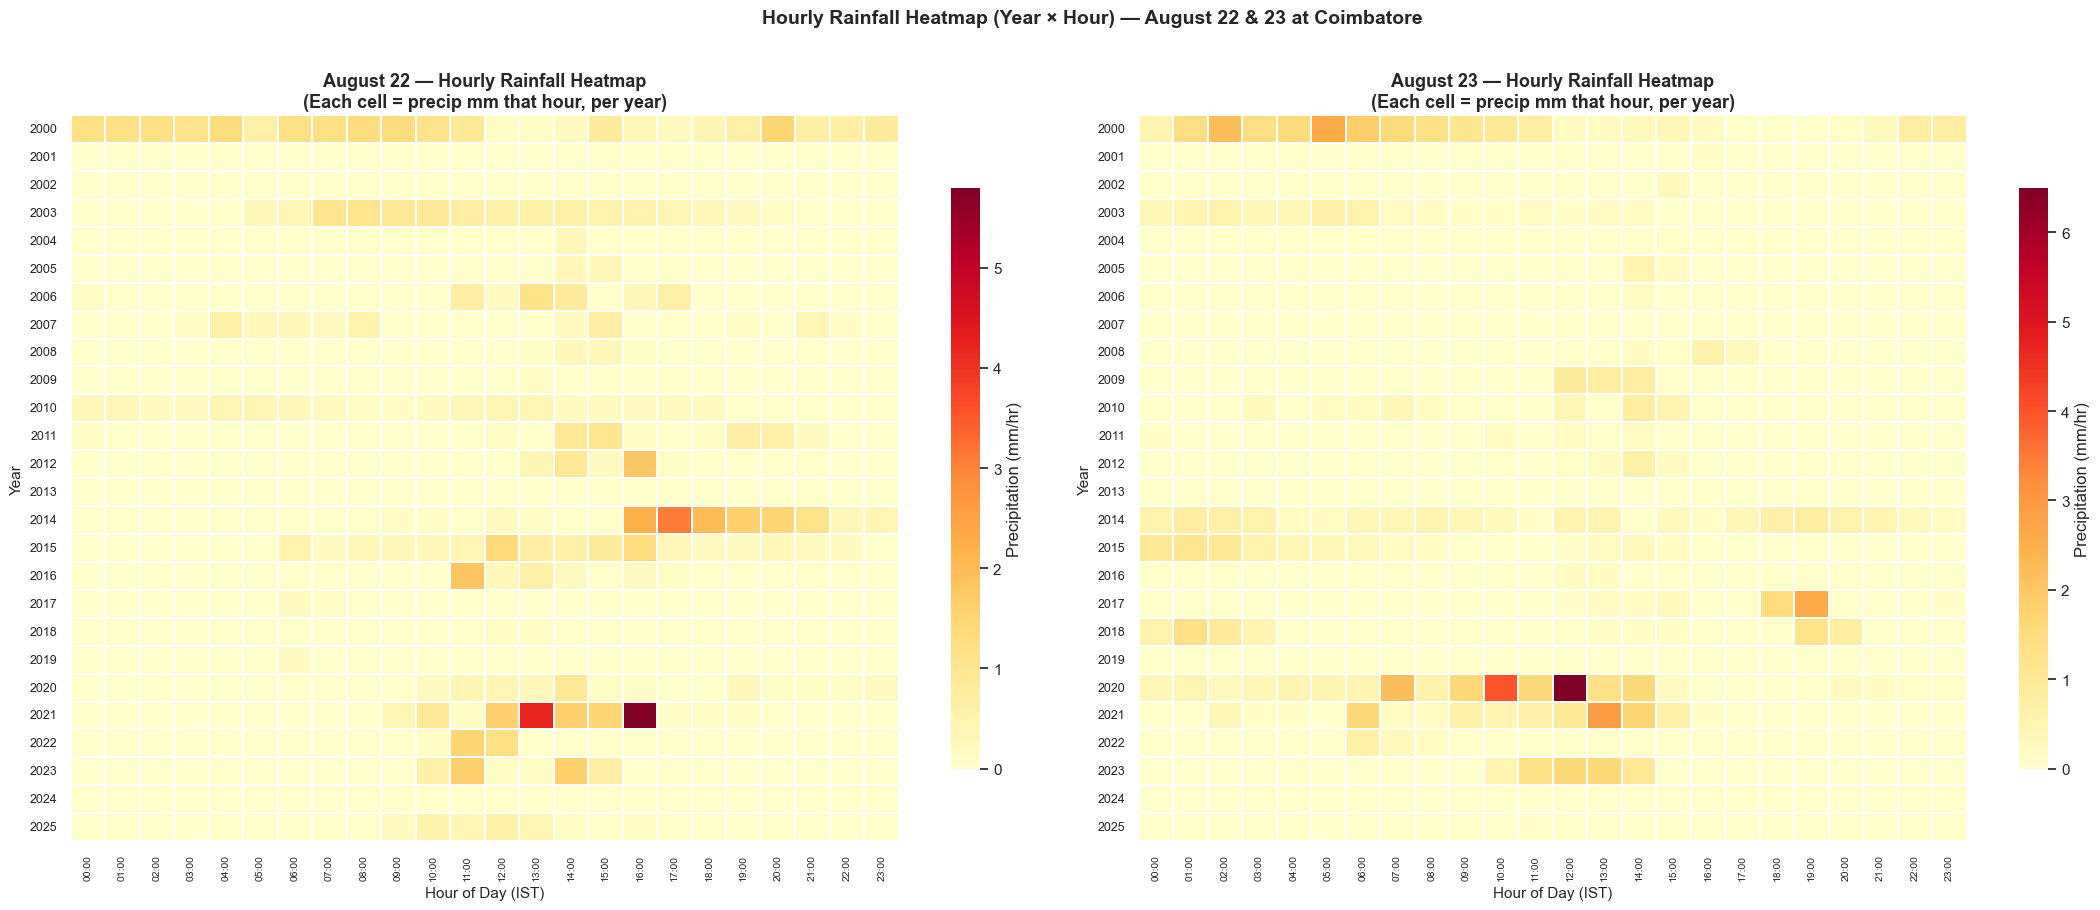

In [38]:
# ── Heatmap: Year × Hour precipitation for Aug 22 & Aug 23 ──
fig, axes = plt.subplots(1, 2, figsize=(22, 9))

for ax, d in zip(axes, [22, 23]):
    sub = hourly_aug[hourly_aug["day"] == d]

    # Pivot: rows = year, columns = hour
    pivot = sub.pivot_table(index="year", columns="hour", values="precip_mm", aggfunc="sum").fillna(0)
    pivot.columns = [f"{h:02d}:00" for h in pivot.columns]

    sns.heatmap(
        pivot,
        ax=ax,
        cmap="YlOrRd",
        linewidths=0.3,
        linecolor="white",
        cbar_kws={"label": "Precipitation (mm/hr)", "shrink": 0.8},
        annot=False,
        fmt=".1f",
        vmin=0,
    )
    ax.set_title(f"August {d} — Hourly Rainfall Heatmap\n(Each cell = precip mm that hour, per year)",
                 fontsize=13, fontweight="bold")
    ax.set_xlabel("Hour of Day (IST)", fontsize=11)
    ax.set_ylabel("Year", fontsize=11)
    ax.tick_params(axis="x", rotation=90, labelsize=7.5)
    ax.tick_params(axis="y", labelsize=9)

plt.suptitle("Hourly Rainfall Heatmap (Year × Hour) — August 22 & 23 at Coimbatore",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

In [39]:
# ── Time-band summary: Night / Morning / Afternoon / Evening ──
BAND_DEF = {
    "Night (00–05)":      (0,  6),
    "Morning (06–11)":    (6,  12),
    "Afternoon (12–17)":  (12, 18),
    "Evening (18–23)":    (18, 24),
}

print("=" * 72)
print("  TIME-OF-DAY RAINFALL SUMMARY — August 22 & 23 (IST, 2000–2025)")
print("=" * 72)

band_rows = []
for d in [22, 23]:
    sub = hourly_aug[hourly_aug["day"] == d]
    print(f"\n  📅 August {d}")
    print(f"  {'Band':<22} {'Avg mm':>8} {'Max mm':>8} {'Rain hrs %':>12} {'Dominant?':>10}")
    print(f"  {'─'*62}")

    band_stats = {}
    for band, (h_start, h_end) in BAND_DEF.items():
        band_sub = sub[(sub["hour"] >= h_start) & (sub["hour"] < h_end)]
        avg   = band_sub["precip_mm"].mean()
        mx    = band_sub["precip_mm"].max()
        freq  = band_sub["rain_hour"].mean() * 100
        total = band_sub["precip_mm"].sum()
        band_stats[band] = {"avg": avg, "max": mx, "freq": freq, "total": total}
        band_rows.append({"Date": f"Aug {d}", "Band": band,
                          "Avg mm/hr": round(avg, 3),
                          "Max mm/hr": round(mx, 2),
                          "Rain freq %": round(freq, 1),
                          "Total mm (26yr)": round(total, 1)})

    dominant = max(band_stats, key=lambda k: band_stats[k]["total"])
    for band, s in band_stats.items():
        flag = "⭐ Most rain" if band == dominant else ""
        print(f"  {band:<22} {s['avg']:>8.3f} {s['max']:>8.1f} {s['freq']:>11.1f}% {flag:>10}")

    # Peak single hour
    by_hour = sub.groupby("hour")["precip_mm"].mean()
    peak_hr = by_hour.idxmax()
    print(f"\n  ⏰ Peak single hour (avg across years): {peak_hr:02d}:00–{peak_hr+1:02d}:00 IST "
          f"({by_hour[peak_hr]:.3f} mm/hr avg)")

print(f"\n{'='*72}")

# Clean table display
band_df = pd.DataFrame(band_rows)
display(
    band_df.set_index(["Date","Band"]).style
    .background_gradient(subset=["Rain freq %"], cmap="Blues")
    .background_gradient(subset=["Total mm (26yr)"], cmap="Oranges")
    .format({"Avg mm/hr": "{:.3f}", "Max mm/hr": "{:.1f}",
             "Rain freq %": "{:.1f}%", "Total mm (26yr)": "{:.1f}"})
    .set_caption("Time-Band Rainfall Breakdown — August 22 & 23 (Coimbatore)")
)

  TIME-OF-DAY RAINFALL SUMMARY — August 22 & 23 (IST, 2000–2025)

  📅 August 22
  Band                     Avg mm   Max mm   Rain hrs %  Dominant?
  ──────────────────────────────────────────────────────────────
  Night (00–05)             0.063      1.3        11.5%           
  Morning (06–11)           0.168      1.8        29.5%           
  Afternoon (12–17)         0.330      5.8        50.6% ⭐ Most rain
  Evening (18–23)           0.107      2.0        22.4%           

  ⏰ Peak single hour (avg across years): 16:00–17:00 IST (0.500 mm/hr avg)

  📅 August 23
  Band                     Avg mm   Max mm   Rain hrs %  Dominant?
  ──────────────────────────────────────────────────────────────
  Night (00–05)             0.175      2.6        25.6%           
  Morning (06–11)           0.194      4.0        27.6%           
  Afternoon (12–17)         0.221      6.5        38.5% ⭐ Most rain
  Evening (18–23)           0.076      2.6        12.2%           

  ⏰ Peak single hour (avg 

---
## 10. Event-Window Risk Analysis

Focused analysis on the **exact hours the events are running**:

| Event | Date | Window (IST) |
|---|---|---|
| 🥂 Reception | Aug 22 | **18:00 – 23:59** (evening) |
| 🌅 Morning ceremony | Aug 23 | **06:00 – 11:59** (morning) |

For each window we compute:
- Historical rain frequency (how many years had ≥ 0.1 mm in that window)
- Total and average precipitation during the window per year
- Probability of any rain occurring during the event
- Hour-by-hour breakdown within the window

In [45]:
# ── Define event windows ──
EVENT_WINDOWS = {
    "Aug 22 — Reception (18:00–23:59)":    {"day": 22, "h_start": 18, "h_end": 24},
    "Aug 23 — Morning ceremony (05:00–10:59)": {"day": 23, "h_start":  5, "h_end": 11},
}

event_year_rows = []

for event_label, cfg in EVENT_WINDOWS.items():
    day_data = hourly_aug[
        (hourly_aug["day"] == cfg["day"]) &
        (hourly_aug["hour"] >= cfg["h_start"]) &
        (hourly_aug["hour"] < cfg["h_end"])
    ].copy()

    # Per-year totals during the window
    by_year = day_data.groupby("year").agg(
        window_total_mm = ("precip_mm", "sum"),
        rainy_hours     = ("rain_hour", "sum"),
        window_hours    = ("precip_mm", "count"),
    ).reset_index()
    by_year["rained_in_window"] = by_year["window_total_mm"] >= 0.1
    by_year["event"] = event_label

    event_year_rows.append(by_year)

event_df = pd.concat(event_year_rows, ignore_index=True)

# ── Print summary per event ──
print("=" * 70)
print("  EVENT-WINDOW RAIN RISK — Coimbatore (2000–2025)")
print("=" * 70)

for event_label in EVENT_WINDOWS:
    sub = event_df[event_df["event"] == event_label]
    n          = len(sub)
    rain_yrs   = sub["rained_in_window"].sum()
    p_emp      = rain_yrs / n
    avg_total  = sub["window_total_mm"].mean()
    avg_when_rain = sub.loc[sub["rained_in_window"], "window_total_mm"].mean()
    max_total  = sub["window_total_mm"].max()
    max_yr     = sub.loc[sub["window_total_mm"].idxmax(), "year"]
    dry_yrs    = n - rain_yrs

    print(f"\n  🎉 {event_label}")
    print(f"     Rain in window (≥0.1mm)   : {rain_yrs}/{n} years  →  {p_emp*100:.0f}% probability")
    print(f"     Dry windows               : {dry_yrs}/{n} years  →  {(1-p_emp)*100:.0f}% chance of staying dry")
    print(f"     Avg precipitation         : {avg_total:.2f} mm (across all {n} years)")
    print(f"     Avg when it does rain     : {avg_when_rain:.2f} mm")
    print(f"     Heaviest window ever      : {max_total:.1f} mm  (in {max_yr})")

print(f"\n{'='*70}")

  EVENT-WINDOW RAIN RISK — Coimbatore (2000–2025)

  🎉 Aug 22 — Reception (18:00–23:59)
     Rain in window (≥0.1mm)   : 9/26 years  →  35% probability
     Dry windows               : 17/26 years  →  65% chance of staying dry
     Avg precipitation         : 0.64 mm (across all 26 years)
     Avg when it does rain     : 1.86 mm
     Heaviest window ever      : 6.9 mm  (in 2014)

  🎉 Aug 23 — Morning ceremony (05:00–10:59)
     Rain in window (≥0.1mm)   : 10/26 years  →  38% probability
     Dry windows               : 16/26 years  →  62% chance of staying dry
     Avg precipitation         : 1.16 mm (across all 26 years)
     Avg when it does rain     : 3.01 mm
     Heaviest window ever      : 9.4 mm  (in 2000)



In [47]:
# ── Year-by-year table for each event window ──
for event_label in EVENT_WINDOWS:
    sub = event_df[event_df["event"] == event_label][
        ["year", "window_total_mm", "rainy_hours", "window_hours", "rained_in_window"]
    ].set_index("year").sort_index()
    sub.index.name = "Year"
    sub.columns = ["Total mm in window", "Rainy hours", "Total hours", "Rain in window?"]
    sub["Rain in window?"] = sub["Rain in window?"].map({True: "🌧 Yes", False: "☀ No"})

    def hl(val):
        if isinstance(val, str):
            return "background-color: #cce5ff; font-weight:bold" if "Yes" in val else "background-color: #fff8dc"
        if isinstance(val, float):
            return "background-color: #d4edda; font-weight:bold" if val >= 0.1 else ""
        return ""

    print(f"\n{event_label}")
    display(
        sub.style
        .map(hl)
        .format({"Total mm in window": "{:.2f}"})
        .bar(subset=["Total mm in window"], color="#90CAF9", vmin=0)
        .set_caption(f"Year-by-Year: {event_label}")
        .set_table_styles([{"selector": "caption",
                            "props": [("font-size","13px"),("font-weight","bold")]}])
    )


Aug 22 — Reception (18:00–23:59)


,Total mm in window,Rainy hours,Total hours,Rain in window?
Year,,,,
2000,4.70,6,6,🌧 Yes
2001,0.00,0,6,☀ No
2002,0.00,0,6,☀ No
2003,0.60,3,6,🌧 Yes
2004,0.00,0,6,☀ No
2005,0.00,0,6,☀ No
2006,0.00,0,6,☀ No
2007,0.60,3,6,🌧 Yes
2008,0.00,0,6,☀ No



Aug 23 — Morning ceremony (05:00–10:59)


,Total mm in window,Rainy hours,Total hours,Rain in window?
Year,,,,
2000,9.40,6,6,🌧 Yes
2001,0.00,0,6,☀ No
2002,0.00,0,6,☀ No
2003,1.90,6,6,🌧 Yes
2004,0.00,0,6,☀ No
2005,0.00,0,6,☀ No
2006,0.00,0,6,☀ No
2007,0.00,0,6,☀ No
2008,0.00,0,6,☀ No


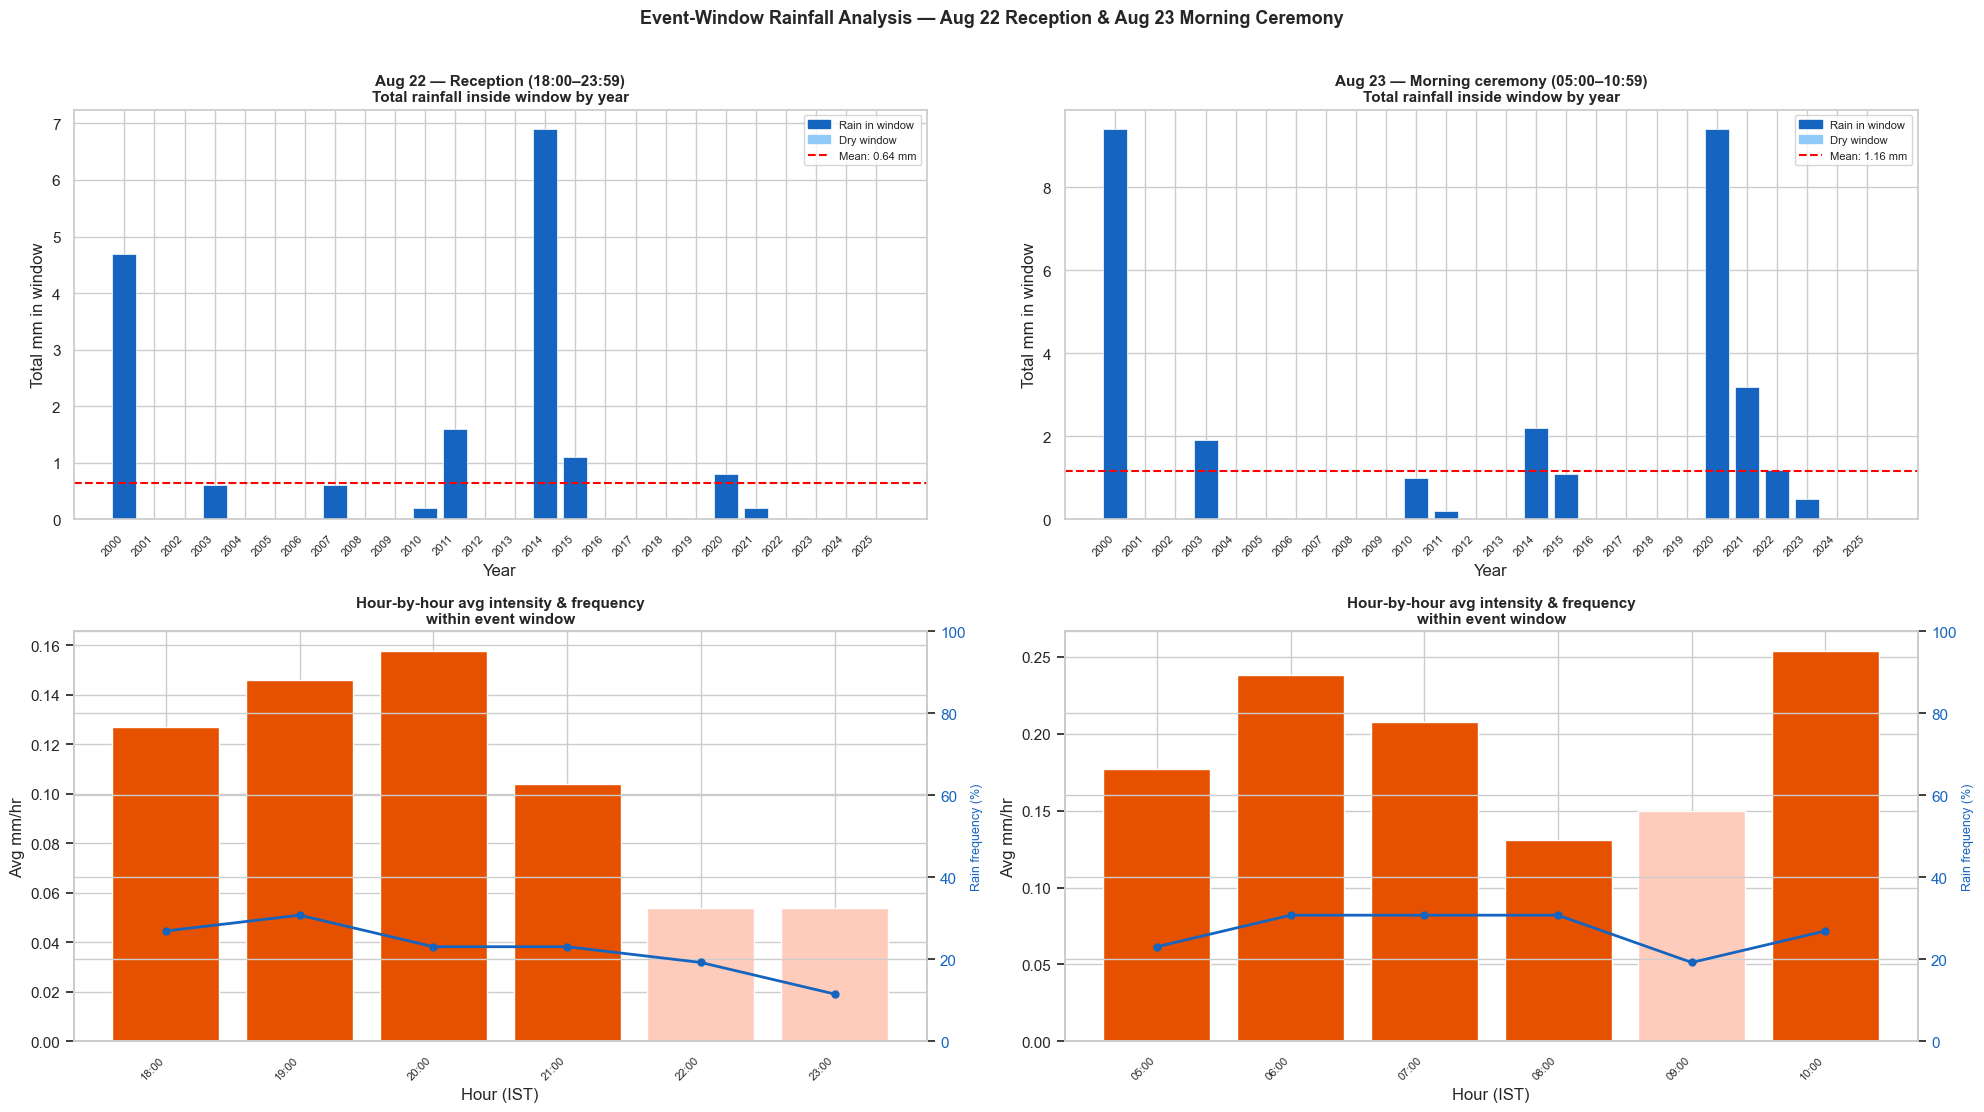

In [48]:
# ── Chart 1: Year-by-year window rainfall bars + hourly breakdown ──
fig, axes = plt.subplots(2, 2, figsize=(20, 11))

EVENT_LIST = list(EVENT_WINDOWS.items())

for col, (event_label, cfg) in enumerate(EVENT_LIST):
    # ── Top row: total precipitation per year in this window ──
    sub_yr = event_df[event_df["event"] == event_label].sort_values("year")
    colors_yr = ["#1565C0" if r else "#90CAF9" for r in sub_yr["rained_in_window"]]

    ax_top = axes[0, col]
    bars = ax_top.bar(sub_yr["year"], sub_yr["window_total_mm"],
                      color=colors_yr, edgecolor="white", linewidth=0.5)
    mean_w = sub_yr["window_total_mm"].mean()
    ax_top.axhline(mean_w, color="red", linestyle="--", linewidth=1.5,
                   label=f"Mean: {mean_w:.2f} mm")
    ax_top.set_title(f"{event_label}\nTotal rainfall inside window by year",
                     fontsize=11, fontweight="bold")
    ax_top.set_xlabel("Year"); ax_top.set_ylabel("Total mm in window")
    ax_top.set_xticks(sub_yr["year"])
    ax_top.set_xticklabels(sub_yr["year"], rotation=45, ha="right", fontsize=8)
    ax_top.legend(fontsize=9)

    rain_patch = mpatches.Patch(color="#1565C0", label="Rain in window")
    dry_patch  = mpatches.Patch(color="#90CAF9", label="Dry window")
    ax_top.legend(handles=[rain_patch, dry_patch,
                  plt.Line2D([0],[0], color="red", linestyle="--", label=f"Mean: {mean_w:.2f} mm")],
                  fontsize=8)

    # ── Bottom row: avg precip per hour within the window (across all years) ──
    day_hrs = hourly_aug[
        (hourly_aug["day"] == cfg["day"]) &
        (hourly_aug["hour"] >= cfg["h_start"]) &
        (hourly_aug["hour"] < cfg["h_end"])
    ]
    by_hr = day_hrs.groupby("hour").agg(
        avg_mm   = ("precip_mm", "mean"),
        rain_pct = ("rain_hour", lambda x: x.mean() * 100)
    ).reset_index()

    ax_bot = axes[1, col]
    c_hr = ["#E65100" if p >= 20 else "#FFCCBC" for p in by_hr["rain_pct"]]
    ax_bot.bar(by_hr["hour"], by_hr["avg_mm"], color=c_hr, edgecolor="white")

    ax2 = ax_bot.twinx()
    ax2.plot(by_hr["hour"], by_hr["rain_pct"], color="#1565C0",
             marker="o", linewidth=2, markersize=5, label="Rain freq %")
    ax2.set_ylabel("Rain frequency (%)", color="#1565C0", fontsize=9)
    ax2.tick_params(axis="y", labelcolor="#1565C0")
    ax2.set_ylim(0, 100)

    ax_bot.set_title(f"Hour-by-hour avg intensity & frequency\nwithin event window",
                     fontsize=11, fontweight="bold")
    ax_bot.set_xlabel("Hour (IST)"); ax_bot.set_ylabel("Avg mm/hr")
    ax_bot.set_xticks(by_hr["hour"])
    ax_bot.set_xticklabels([f"{h:02d}:00" for h in by_hr["hour"]], rotation=45, ha="right", fontsize=8)

plt.suptitle("Event-Window Rainfall Analysis — Aug 22 Reception & Aug 23 Morning Ceremony",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

In [49]:
# ── Final event-window verdict ──
print("╔" + "═"*68 + "╗")
print("║  WEDDING EVENT RAIN RISK VERDICT — Coimbatore 2026" + " "*17 + "║")
print("╠" + "═"*68 + "╣")

for event_label, cfg in EVENT_WINDOWS.items():
    sub = event_df[event_df["event"] == event_label]
    n         = len(sub)
    rain_yrs  = sub["rained_in_window"].sum()
    p_emp     = rain_yrs / n
    avg_total = sub["window_total_mm"].mean()
    avg_rain  = sub.loc[sub["rained_in_window"], "window_total_mm"].mean()

    risk = "🔴 HIGH" if p_emp >= 0.5 else ("🟡 MODERATE" if p_emp >= 0.3 else "🟢 LOW")
    print(f"║                                                                    ║")
    print(f"║  🎉 {event_label:<62} ║")
    print(f"║     Risk level         : {risk:<43} ║")
    print(f"║     P(rain in window)  : {p_emp*100:.0f}% ({rain_yrs}/{n} years had rain)          ║")
    print(f"║     Avg precip/window  : {avg_total:.2f} mm  |  Avg when rainy: {avg_rain:.2f} mm       ║")

print(f"║                                                                    ║")
print("╠" + "═"*68 + "╣")
print("║  💡 Tip: The afternoon (12–17h) is the highest-risk period overall. ║")
print("║     The 18:00 reception AVOIDS the peak risk window.               ║")
print("║     The 06:00 morning ceremony is in a drier band but not dry.     ║")
print("╚" + "═"*68 + "╝")

╔════════════════════════════════════════════════════════════════════╗
║  WEDDING EVENT RAIN RISK VERDICT — Coimbatore 2026                 ║
╠════════════════════════════════════════════════════════════════════╣
║                                                                    ║
║  🎉 Aug 22 — Reception (18:00–23:59)                               ║
║     Risk level         : 🟡 MODERATE                                  ║
║     P(rain in window)  : 35% (9/26 years had rain)          ║
║     Avg precip/window  : 0.64 mm  |  Avg when rainy: 1.86 mm       ║
║                                                                    ║
║  🎉 Aug 23 — Morning ceremony (05:00–10:59)                        ║
║     Risk level         : 🟡 MODERATE                                  ║
║     P(rain in window)  : 38% (10/26 years had rain)          ║
║     Avg precip/window  : 1.16 mm  |  Avg when rainy: 3.01 mm       ║
║                                                                    ║
╠════════════════

---
## 11. August Monthly Rainfall — Full Historical Record (2000–2025)

Year-by-year totals for the entire month of August, including total rainfall, rain days, peak daily rainfall, and the rolling 5-year average trend.


In [ ]:
# ── August monthly rainfall: styled year-by-year table ──
aug_hist = aug_by_year[["total_mm", "rain_days", "max_daily_mm", "mean_daily_mm", "rain_day_%"]].copy()
aug_hist.columns = ["Total mm", "Rain days", "Peak day mm", "Avg daily mm", "Rain day %"]
aug_hist.index.name = "Year"

mean_total = aug_hist["Total mm"].mean()
median_total = aug_hist["Total mm"].median()

print(f"August Rainfall — Coimbatore {aug_hist.index.min()}–{aug_hist.index.max()}")
print(f"26-year mean: {mean_total:.0f} mm  |  Median: {median_total:.0f} mm  |  "
      f"Wettest: {aug_hist['Total mm'].max():.0f} mm ({aug_hist['Total mm'].idxmax()})  |  "
      f"Driest: {aug_hist['Total mm'].min():.0f} mm ({aug_hist['Total mm'].idxmin()})")
print()

def highlight_august(row):
    styles = [""] * len(row)
    total = row["Total mm"]
    if total >= mean_total * 1.3:
        styles[0] = "background-color: #0d47a1; color: white; font-weight: bold"   # very wet
    elif total >= mean_total:
        styles[0] = "background-color: #90caf9; font-weight: bold"                  # above avg
    elif total <= mean_total * 0.7:
        styles[0] = "background-color: #fff9c4"                                      # dry
    return styles

display(
    aug_hist.style
    .apply(highlight_august, axis=1)
    .background_gradient(subset=["Rain days"], cmap="Blues", vmin=0, vmax=31)
    .background_gradient(subset=["Peak day mm"], cmap="Oranges")
    .bar(subset=["Rain day %"], color="#4CAF50", vmin=0, vmax=100)
    .format({
        "Total mm":    "{:.1f}",
        "Rain days":   "{:.0f}",
        "Peak day mm": "{:.1f}",
        "Avg daily mm":"{:.2f}",
        "Rain day %":  "{:.1f}%",
    })
    .set_caption("August Monthly Rainfall — Coimbatore (2000–2025)")
    .set_table_styles([
        {"selector": "caption", "props": [("font-size","14px"),("font-weight","bold")]},
        {"selector": "th",      "props": [("background-color","#263238"),("color","white")]},
    ])
)

August Rainfall — Coimbatore 2000–2025
26-year mean: 145 mm  |  Median: 131 mm  |  Wettest: 394 mm (2017)  |  Driest: 41 mm (2003)



,Total mm,Rain days,Peak day mm,Avg daily mm,Rain day %
Year,,,,,
2000,165.4,22,20.5,5.34,71.0%
2001,66.3,9,17.5,2.14,29.0%
2002,79.4,11,17.9,2.56,35.5%
2003,41.1,13,9.0,1.33,41.9%
2004,45.5,9,11.5,1.47,29.0%
2005,45.0,8,15.1,1.45,25.8%
2006,48.1,11,8.5,1.55,35.5%
2007,114.8,17,17.9,3.70,54.8%
2008,131.2,21,38.7,4.23,67.7%


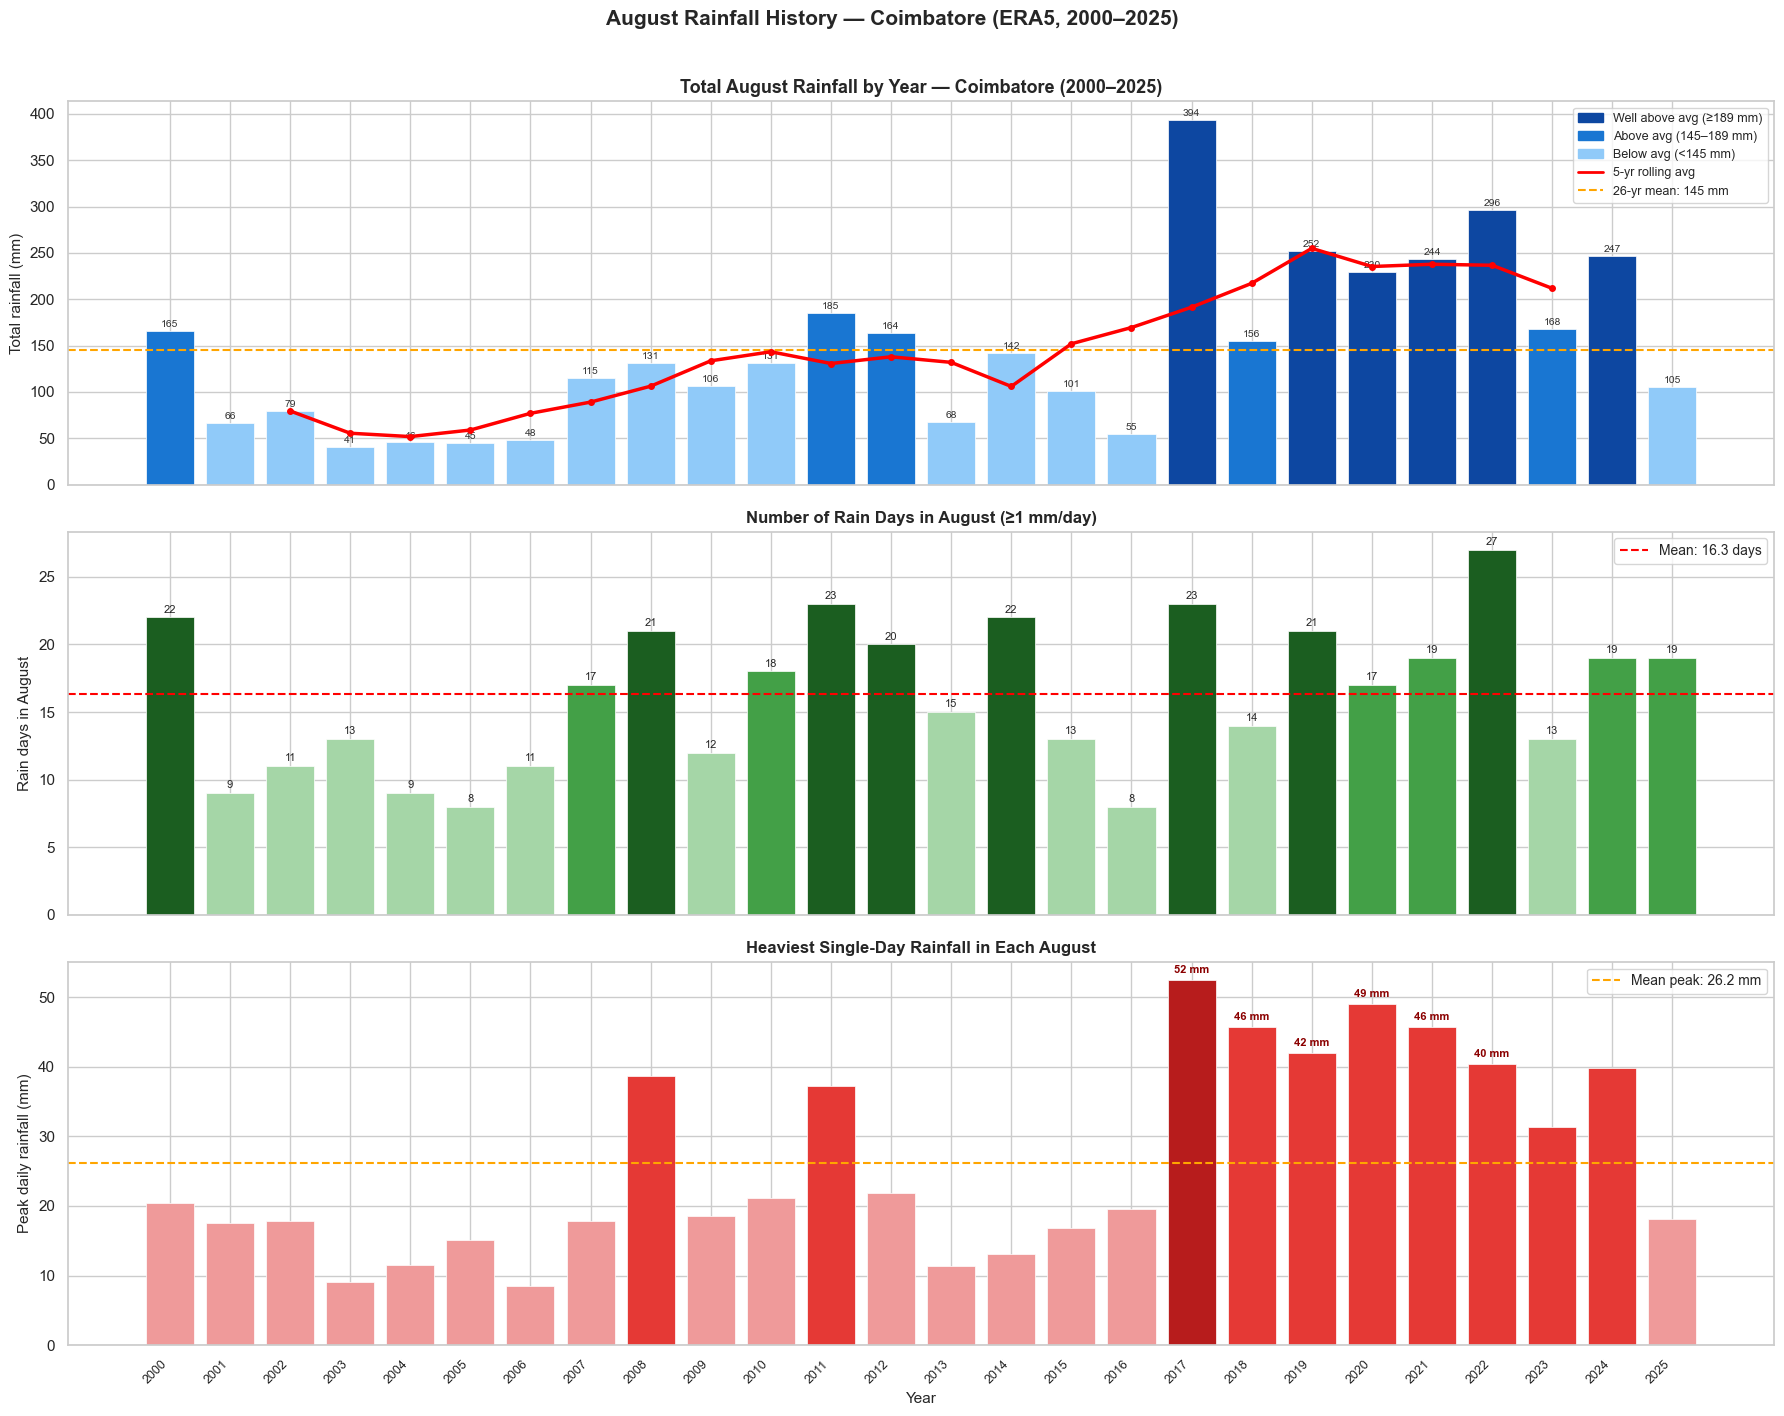

In [51]:
# ── August monthly rainfall: 3-panel chart ──
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(18, 14), sharex=True)
years_idx = aug_by_year.index.values
mean_t    = aug_by_year["total_mm"].mean()

# Rolling 5-year average
roll5 = aug_by_year["total_mm"].rolling(5, center=True).mean()

# ── Panel 1: Total monthly rainfall with 5-yr rolling avg ──
bar_colors = ["#0d47a1" if v >= mean_t * 1.3
              else "#1976D2" if v >= mean_t
              else "#90CAF9" for v in aug_by_year["total_mm"]]
bars1 = ax1.bar(years_idx, aug_by_year["total_mm"], color=bar_colors,
                edgecolor="white", linewidth=0.5, width=0.8)
ax1.plot(years_idx, roll5, color="red", linewidth=2.5, marker="o",
         markersize=4, label="5-yr rolling avg", zorder=5)
ax1.axhline(mean_t, color="orange", linestyle="--", linewidth=1.5,
            label=f"26-yr mean: {mean_t:.0f} mm")
ax1.set_ylabel("Total rainfall (mm)", fontsize=11)
ax1.set_title("Total August Rainfall by Year — Coimbatore (2000–2025)",
              fontsize=13, fontweight="bold")
ax1.legend(fontsize=10)
for bar, val in zip(bars1, aug_by_year["total_mm"]):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
             f"{val:.0f}", ha="center", va="bottom", fontsize=7.5, color="#333")

dark_patch  = mpatches.Patch(color="#0d47a1", label=f"Well above avg (≥{mean_t*1.3:.0f} mm)")
mid_patch   = mpatches.Patch(color="#1976D2", label=f"Above avg ({mean_t:.0f}–{mean_t*1.3:.0f} mm)")
light_patch = mpatches.Patch(color="#90CAF9", label=f"Below avg (<{mean_t:.0f} mm)")
ax1.legend(handles=[dark_patch, mid_patch, light_patch,
                    plt.Line2D([0],[0], color="red", linewidth=2, label="5-yr rolling avg"),
                    plt.Line2D([0],[0], color="orange", linestyle="--", linewidth=1.5,
                               label=f"26-yr mean: {mean_t:.0f} mm")],
           fontsize=9, loc="upper right")

# ── Panel 2: Rain days per August ──
mean_rd = aug_by_year["rain_days"].mean()
rd_colors = ["#1B5E20" if v >= mean_rd * 1.2 else "#43A047" if v >= mean_rd else "#A5D6A7"
             for v in aug_by_year["rain_days"]]
ax2.bar(years_idx, aug_by_year["rain_days"], color=rd_colors, edgecolor="white",
        linewidth=0.5, width=0.8)
ax2.axhline(mean_rd, color="red", linestyle="--", linewidth=1.5,
            label=f"Mean: {mean_rd:.1f} days")
ax2.set_ylabel("Rain days in August", fontsize=11)
ax2.set_title("Number of Rain Days in August (≥1 mm/day)", fontsize=12, fontweight="bold")
ax2.legend(fontsize=10)
for i, (yr, v) in enumerate(zip(years_idx, aug_by_year["rain_days"])):
    ax2.text(yr, v + 0.2, f"{v:.0f}", ha="center", va="bottom", fontsize=8)

# ── Panel 3: Peak single-day rainfall per August ──
pk_colors = ["#B71C1C" if v >= 50 else "#E53935" if v >= 25 else "#EF9A9A"
             for v in aug_by_year["max_daily_mm"]]
ax3.bar(years_idx, aug_by_year["max_daily_mm"], color=pk_colors, edgecolor="white",
        linewidth=0.5, width=0.8)
ax3.axhline(aug_by_year["max_daily_mm"].mean(), color="orange", linestyle="--",
            linewidth=1.5, label=f"Mean peak: {aug_by_year['max_daily_mm'].mean():.1f} mm")
ax3.set_ylabel("Peak daily rainfall (mm)", fontsize=11)
ax3.set_title("Heaviest Single-Day Rainfall in Each August", fontsize=12, fontweight="bold")
ax3.set_xlabel("Year", fontsize=11)
ax3.set_xticks(years_idx)
ax3.set_xticklabels(years_idx, rotation=45, ha="right", fontsize=9)
ax3.legend(fontsize=10)
for yr, v in zip(years_idx, aug_by_year["max_daily_mm"]):
    if v >= 40:
        ax3.annotate(f"{v:.0f} mm", xy=(yr, v), xytext=(0, 5),
                     textcoords="offset points", ha="center", fontsize=8,
                     color="darkred", fontweight="bold")

plt.suptitle("August Rainfall History — Coimbatore (ERA5, 2000–2025)",
             fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()
